# [STARTER] Udaplay Project

## Part 01 - Offline RAG

In this part of the project, you'll build your VectorDB using Chroma.

The data is inside folder `project/starter/games`. Each file will become a document in the collection you'll create.
Example.:
```json
{
  "Name": "Gran Turismo",
  "Platform": "PlayStation 1",
  "Genre": "Racing",
  "Publisher": "Sony Computer Entertainment",
  "Description": "A realistic racing simulator featuring a wide array of cars and tracks, setting a new standard for the genre.",
  "YearOfRelease": 1997
}
```


### Setup

In [8]:
# Only needed for Udacity workspace

import importlib.util
import sys

# Check if 'pysqlite3' is available before importing
if importlib.util.find_spec("pysqlite3") is not None:
    import pysqlite3
    sys.modules['sqlite3'] = sys.modules.pop('pysqlite3')

In [9]:
import os
import json
import chromadb
from chromadb.utils import embedding_functions
from dotenv import load_dotenv

In [ ]:
# TODO: Create a .env file with the following variables
# OPENAI_API_KEY="YOUR_KEY"
# CHROMA_OPENAI_API_KEY="YOUR_KEY"
# TAVILY_API_KEY="YOUR_KEY"

In [10]:
# Load environment variables used by the embedding function.
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("OPENAI_API_KEY is required to create embeddings.")

### VectorDB Instance

In [11]:
# TODO: Instantiate your ChromaDB Client
# Choose any path you want
chroma_client = chromadb.PersistentClient(path="chromadb")

### Collection

In [12]:
# Use the same embedding function when indexing and querying the collection.
embedding_fn = embedding_functions.OpenAIEmbeddingFunction(
    api_key=OPENAI_API_KEY
)

In [13]:
# Reuse the collection when the notebook is run more than once.
collection = chroma_client.get_or_create_collection(
    name="udaplay",
    embedding_function=embedding_fn,
)

### Add documents

In [14]:
# Load every JSON game and upsert it so indexing is safe to rerun.
data_dir = "games"
ids = []
documents = []
metadatas = []

for file_name in sorted(os.listdir(data_dir)):
    if not file_name.endswith(".json"):
        continue

    file_path = os.path.join(data_dir, file_name)
    with open(file_path, "r", encoding="utf-8") as file:
        game = json.load(file)

    ids.append(os.path.splitext(file_name)[0])
    documents.append(
        f"[{game['Platform']}] {game['Name']} ({game['YearOfRelease']}) - {game['Description']}"
    )
    metadatas.append(game)

collection.upsert(
    ids=ids,
    documents=documents,
    metadatas=metadatas,
)
print(f"Indexed {len(ids)} game records")
print(f"Collection count: {collection.count()}")

Indexed 30 game records
Collection count: 30


### Semantic Search

The query below searches the embedded game descriptions semantically. Chroma ranks the closest matches by distance; lower distance means a closer match.

In [20]:
def search_games(query: str, n_results: int = 5) -> list[dict]:
    """Return the games most semantically similar to a natural-language query."""
    results = collection.query(
        query_texts=[query],
        n_results=n_results,
        include=["documents", "metadatas", "distances"],
    )
    documents = results.get("documents", [[]])[0]
    metadatas = results.get("metadatas", [[]])[0]
    distances = results.get("distances", [[]])[0]
    return [
        {
            "document": document,
            "metadata": metadata,
            "distance": distance,
        }
        for document, metadata, distance in zip(documents, metadatas, distances)
    ]


query = "Which PC games are racing games?"
search_results = search_games(query)

print(f"Query: {query}")
print(f"Matches found: {len(search_results)}\n")
for rank, result in enumerate(search_results, start=1):
    metadata = result["metadata"]
    print(f"{rank}. {metadata['Name']} ({metadata['Platform']}, {metadata['YearOfRelease']})")
    print(f"   Distance: {result['distance']:.4f}")
    print(f"   Description: {metadata['Description']}")
    print(f"   Reception: {metadata.get('Reception', 'Unavailable')}")
    print()

Query: Which PC games are racing games?
Matches found: 5

1. Gran Turismo (PlayStation 1, 1997)
   Distance: 0.1693
   Description: A realistic racing simulator featuring a wide array of cars and tracks, setting a new standard for the genre.
   Reception: Universally acclaimed at release for its realistic driving model, presentation, and large car roster; it helped establish console racing simulation as a major genre.

2. Gran Turismo 5 (PlayStation 3, 2010)
   Distance: 0.1700
   Description: A comprehensive racing simulator featuring a vast selection of vehicles and tracks, with realistic driving physics.
   Reception: Generally received favorably for its enormous content offering, driving model, and visual presentation, while critics often mentioned uneven car models, menus, and online issues.

3. Mario Kart 8 (Wii U, 2014)
   Distance: 0.2005
   Description: A colorful kart racing game featuring anti-gravity tracks, familiar Nintendo characters, and online competition.
   Reception

### Retrieval Process Dashboard

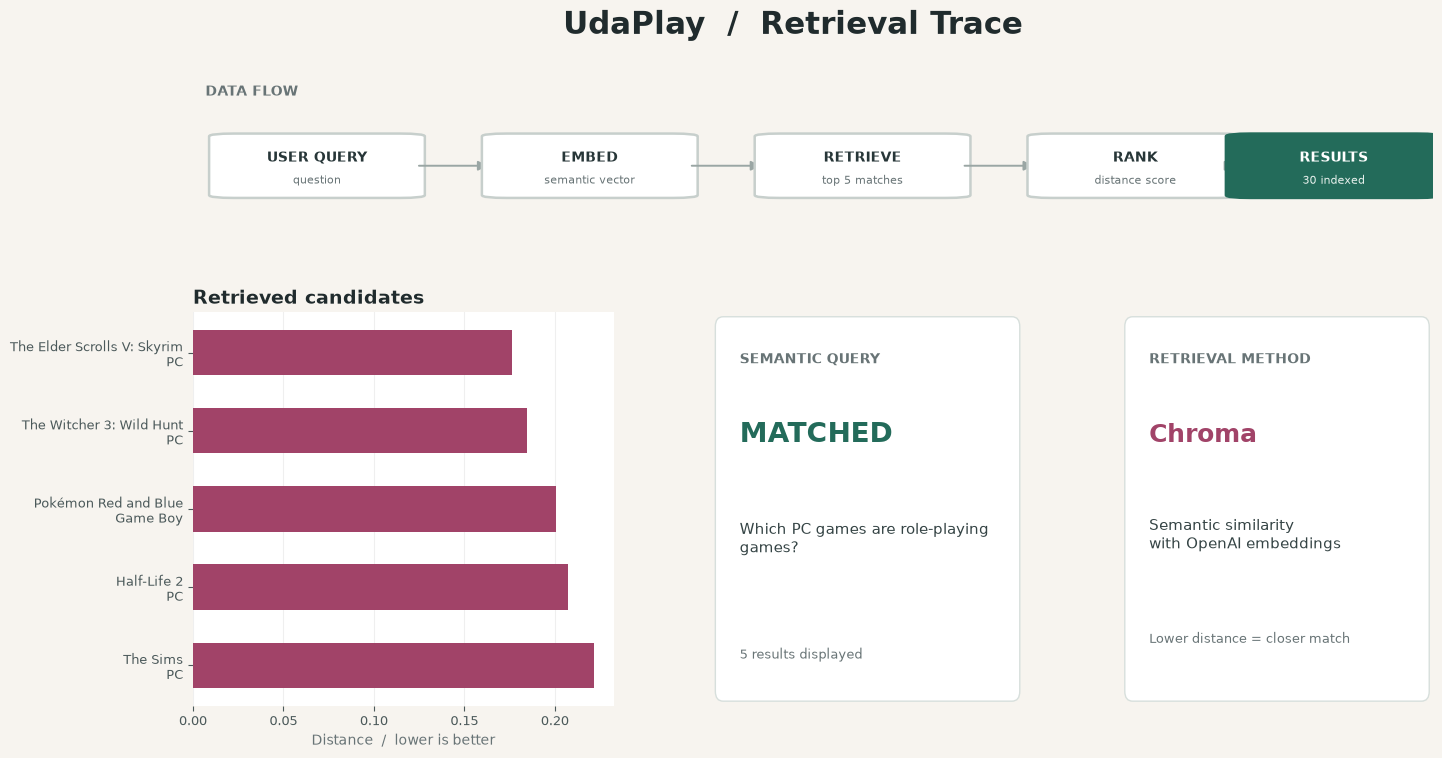

In [17]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from textwrap import wrap

import matplotlib.pyplot as plt


def show_retrieval_process_dashboard(
    query: str = "Which PC games are role-playing games?",
    n_results: int = 5,
) -> None:
    """Visualize the semantic retrieval flow and ranked results."""
    results = search_games(query, n_results=n_results)
    labels = [
        f"{item['metadata'].get('Name', 'Unknown')}\n{item['metadata'].get('Platform', 'Unknown')}"
        for item in results
    ]
    distances = [item["distance"] for item in results]

    figure = plt.figure(figsize=(16, 8), facecolor="#f7f4ef")
    grid = figure.add_gridspec(
        2,
        3,
        height_ratios=[0.9, 2.5],
        width_ratios=[1.35, 1, 1],
        hspace=0.3,
        wspace=0.28,
    )
    figure.suptitle("UdaPlay  /  Retrieval Trace", fontsize=22, fontweight="bold", color="#202b2d", y=0.98)

    flow_axis = figure.add_subplot(grid[0, :])
    flow_axis.set_axis_off()
    flow_axis.set_xlim(0, 1)
    flow_axis.set_ylim(0, 1)
    flow_axis.text(0.01, 0.96, "DATA FLOW", fontsize=10, fontweight="bold", color="#687476")

    flow_nodes = [
        (0.10, "USER QUERY", "question"),
        (0.32, "EMBED", "semantic vector"),
        (0.54, "RETRIEVE", f"top {len(results)} matches"),
        (0.76, "RANK", "distance score"),
        (0.92, "RESULTS", f"{collection.count()} indexed"),
    ]
    for index, (x, title, detail) in enumerate(flow_nodes):
        flow_axis.add_patch(
            FancyBboxPatch(
                (x - 0.075, 0.25),
                0.15,
                0.43,
                boxstyle="round,pad=0.012,rounding_size=0.02",
                facecolor="#236b5a" if title == "RESULTS" else "#ffffff",
                edgecolor="#236b5a" if title == "RESULTS" else "#c7cfcc",
                linewidth=1.8,
            )
        )
        flow_axis.text(x, 0.52, title, ha="center", va="center", fontsize=10, fontweight="bold", color="#ffffff" if title == "RESULTS" else "#273638")
        flow_axis.text(x, 0.36, detail, ha="center", va="center", fontsize=8, color="#e8f1ed" if title == "RESULTS" else "#687476")
        if index < len(flow_nodes) - 1:
            next_x = flow_nodes[index + 1][0]
            flow_axis.add_patch(
                FancyArrowPatch((x + 0.08, 0.465), (next_x - 0.08, 0.465), arrowstyle="-|>", mutation_scale=14, linewidth=1.4, color="#9aa6a4")
            )

    candidates_axis = figure.add_subplot(grid[1, 0])
    candidates_axis.set_facecolor("#ffffff")
    candidates_axis.barh(labels[::-1], distances[::-1], color="#a14368", height=0.58)
    candidates_axis.set_title("Retrieved candidates", loc="left", fontsize=14, fontweight="bold", color="#202b2d")
    candidates_axis.set_xlabel("Distance  /  lower is better", color="#687476")
    candidates_axis.tick_params(axis="both", labelsize=9, colors="#4b595a")
    candidates_axis.grid(axis="x", alpha=0.2)
    candidates_axis.set_axisbelow(True)
    for spine in candidates_axis.spines.values():
        spine.set_visible(False)

    query_axis = figure.add_subplot(grid[1, 1])
    query_axis.set_axis_off()
    query_axis.add_patch(FancyBboxPatch((0.03, 0.03), 0.94, 0.94, transform=query_axis.transAxes, boxstyle="round,pad=0.018,rounding_size=0.025", facecolor="#ffffff", edgecolor="#d7dfdc"))
    query_axis.text(0.09, 0.87, "SEMANTIC QUERY", transform=query_axis.transAxes, fontsize=10, fontweight="bold", color="#687476")
    query_axis.text(0.09, 0.67, "MATCHED", transform=query_axis.transAxes, fontsize=20, fontweight="bold", color="#236b5a")
    query_axis.text(0.09, 0.47, "\n".join(wrap(query, 31)), transform=query_axis.transAxes, fontsize=11, color="#354445", va="top")
    query_axis.text(0.09, 0.12, f"{len(results)} results displayed", transform=query_axis.transAxes, fontsize=9, color="#687476")

    method_axis = figure.add_subplot(grid[1, 2])
    method_axis.set_axis_off()
    method_axis.add_patch(FancyBboxPatch((0.03, 0.03), 0.94, 0.94, transform=method_axis.transAxes, boxstyle="round,pad=0.018,rounding_size=0.025", facecolor="#ffffff", edgecolor="#d7dfdc"))
    method_axis.text(0.09, 0.87, "RETRIEVAL METHOD", transform=method_axis.transAxes, fontsize=10, fontweight="bold", color="#687476")
    method_axis.text(0.09, 0.67, "Chroma", transform=method_axis.transAxes, fontsize=18, fontweight="bold", color="#a14368")
    method_axis.text(0.09, 0.48, "Semantic similarity\nwith OpenAI embeddings", transform=method_axis.transAxes, fontsize=11, color="#354445", va="top")
    method_axis.text(0.09, 0.16, "Lower distance = closer match", transform=method_axis.transAxes, fontsize=9, color="#687476")

    plt.show()


show_retrieval_process_dashboard()